## Homework 3
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [63]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector, partial_trace, DensityMatrix
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
%matplotlib inline

$$
\renewcommand{\ket}[1]{\left|#1\right\rangle}
\renewcommand{\bra}[1]{\left\langle#1\right|}
\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
$$

## Problem 1

## (a)

        ┌───┐     ┌───┐ ░ ┌─┐   
   q_0: ┤ H ├──■──┤ H ├─░─┤M├───
        └───┘┌─┴─┐└───┘ ░ └╥┘┌─┐
   q_1: ─────┤ X ├──────░──╫─┤M├
             └───┘      ░  ║ └╥┘
meas: 2/═══════════════════╩══╩═
                           0  1 
Counts(ideal): {'10': 249, '11': 247, '00': 248, '01': 280}


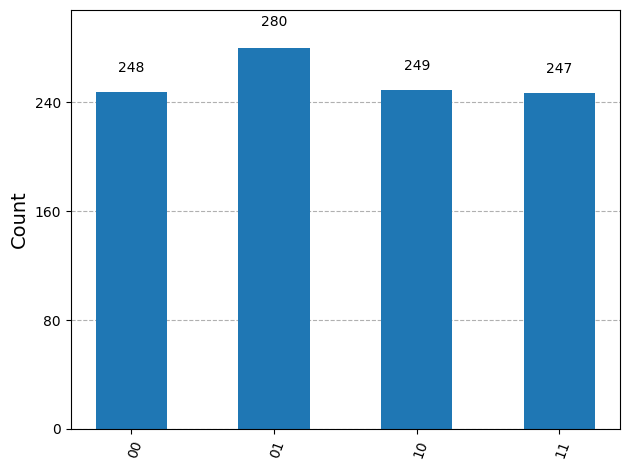

In [ ]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.h(0)
qc.measure_all()
print(qc.draw())
sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

        ┌───┐           ░ ┌─┐   
   q_0: ┤ H ├──■────────░─┤M├───
        └───┘┌─┴─┐┌───┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ H ├─░──╫─┤M├
             └───┘└───┘ ░  ║ └╥┘
meas: 2/═══════════════════╩══╩═
                           0  1 
Counts(ideal): {'11': 270, '10': 247, '01': 257, '00': 250}


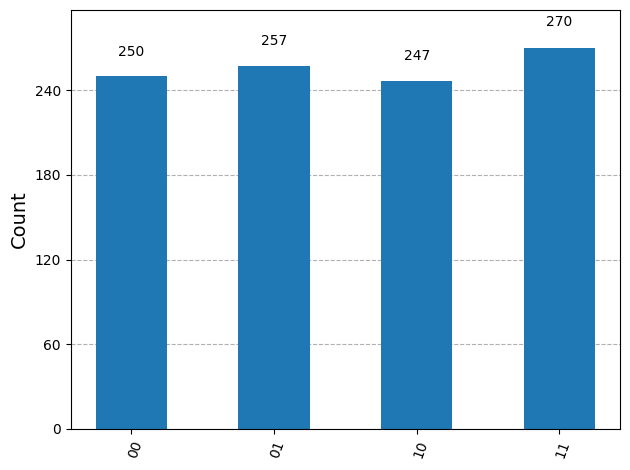

In [11]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.h(1)
qc.measure_all()
print(qc.draw())
sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

## (b)

        ┌───┐     ┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ H ├──■──┤ H ├┤ H ├─░─┤M├───
        └───┘┌─┴─┐├───┤└───┘ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ H ├──────░──╫─┤M├
             └───┘└───┘      ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1 
Counts(ideal): {'11': 269, '01': 263, '10': 248, '00': 244}


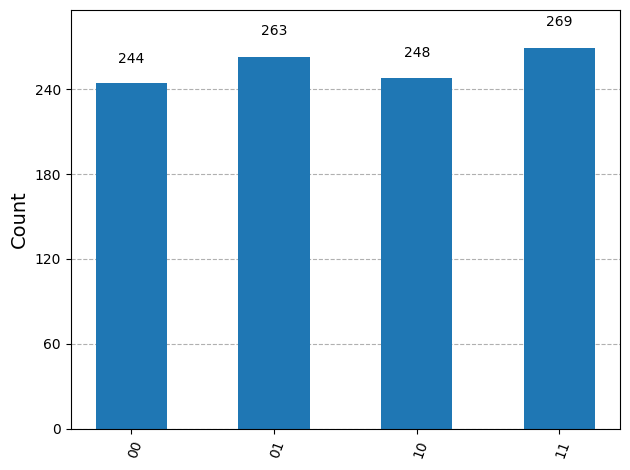

In [12]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.h(0)
qc.h(0)
qc.h(1)
qc.measure_all()
print(qc.draw())
sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

        ┌───┐     ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■──┤ H ├──────░─┤M├───
        └───┘┌─┴─┐├───┤┌───┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ H ├┤ H ├─░──╫─┤M├
             └───┘└───┘└───┘ ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1 
Counts(ideal): {'11': 228, '00': 245, '10': 283, '01': 268}


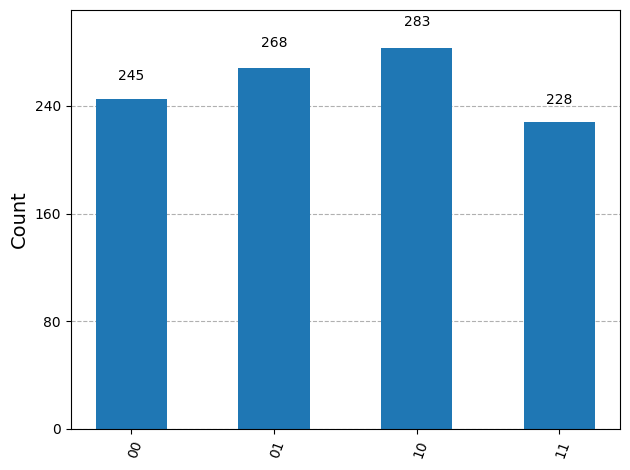

In [52]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.h(1)
qc.h(0)
qc.h(1)
qc.measure_all()
print(qc.draw())
sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

## (c)

$$
U =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix},   
\quad U^T =
\begin{bmatrix}
a & c \\
b & d
\end{bmatrix}
$$

$$
\begin{align*}
(U \otimes I)\ket{\Phi^+} &= \frac{1}{\sqrt{2}}((U\ket{0})\ket{0} + (U\ket{1})\ket{1})\\
&= \frac{1}{\sqrt{2}}((a\ket{0} + c\ket{1})\ket{0} + (b\ket{0} + d\ket{1})\ket{1})\\
&= \frac{1}{\sqrt{2}}(a\ket{00} + b\ket{01} + c\ket{10} + d\ket{11})
\end{align*}
$$

$$
\begin{align*}
(I \otimes U^T)\ket{\Phi^+} &= \frac{1}{\sqrt{2}}(\ket{0}(U^T\ket{0}) + \ket{1}(U^T\ket{1}))\\
&= \frac{1}{\sqrt{2}}(\ket{0}(a\ket{0} + b\ket{1}) + \ket{1}(c\ket{0} + d\ket{1}))\\
&= \frac{1}{\sqrt{2}}(a\ket{00} + b\ket{01} + c\ket{10} + d\ket{11})
\end{align*}
$$

## Problem 2

## (a)

In [36]:
def superdense(bits):
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0,1)
    if bits[0] == "1":
        qc.x(0)
    if bits[1] == "1":
        qc.z(0)
    qc.cx(0,1)
    qc.h(0)
    qc.measure_all()
    return qc

error = 0
for i in range(100):
    bits = np.random.choice(["00","01","10","11"])
    qc = superdense(bits)
    sampler = StatevectorSampler()
    result = sampler.run([qc], shots=1).result()
    counts = result[0].data.meas.get_counts()
    measured = list(counts.keys())[0]
    if bits != measured:
        error += 1
print('Error rate:', error/100)


Error rate: 0.0


## (b)

In [37]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

bits = np.random.choice(["00","01","10","11"], size=100)
circuits = [pm.run(superdense(b)) for b in bits]

job = sampler.run(circuits, shots=1)
result = job.result()

error = 0
for i in range(100):
    counts = result[i].data.meas.get_counts()
    if bits[i] != list(counts.keys())[0]:
        error += 1
print('Error rate:', error/100)



qiskit_runtime_service.__init__:WARNING:2026-02-14 17:38:05,163: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-14 17:38:05,801: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-14 17:38:07,643: Using instance: open-instance, plan: open


Error rate: 0.2


## Problem 3

## (a)

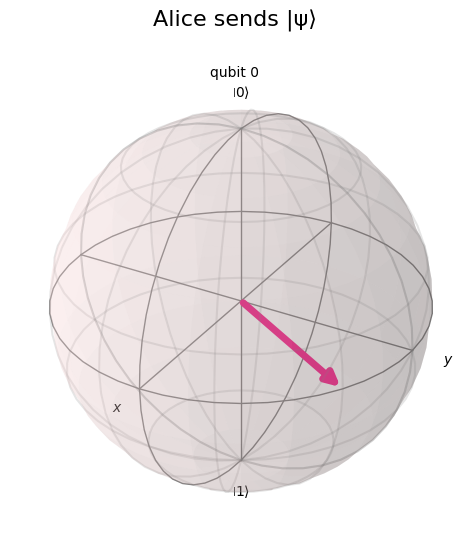

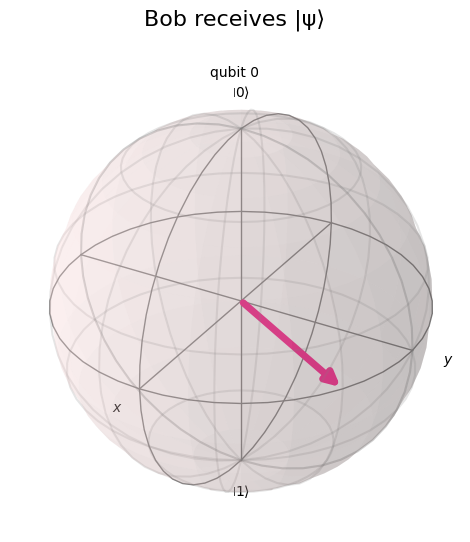

In [71]:
theta = np.pi/2
phi   = np.pi/3
lam   = np.pi/4

qc = QuantumCircuit(1)
qc.u(theta, phi, lam, 0)

plot_bloch_multivector(Statevector(qc), title="Alice sends |ψ⟩")

qc = QuantumCircuit(3)
qc.u(theta, phi, lam, 0)
qc.h(1)
qc.cx(1,2)
qc.cx(0,1)
qc.h(0)

qc.cx(1,2)
qc.cz(0,2)

plot_bloch_multivector(DensityMatrix(partial_trace(Statevector(qc), [0, 1])), title="Bob receives |ψ⟩")

plt.show()

## (b)

Counts: {'1': 515, '0': 509}


qiskit_runtime_service.__init__:WARNING:2026-02-14 18:17:52,143: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-14 18:17:53,069: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-14 18:17:54,812: Using instance: open-instance, plan: open


Counts: {'1': 67, '0': 61}


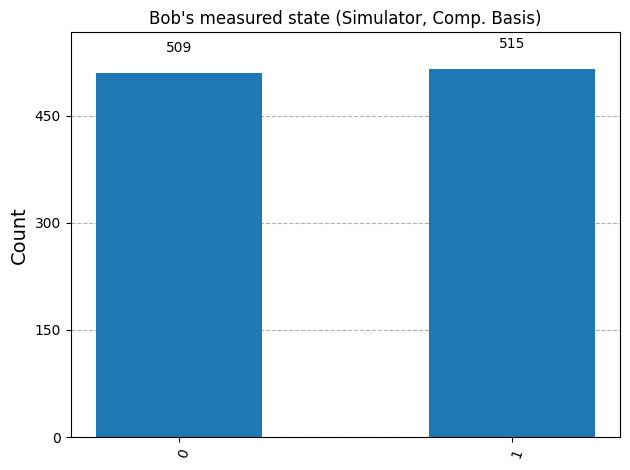

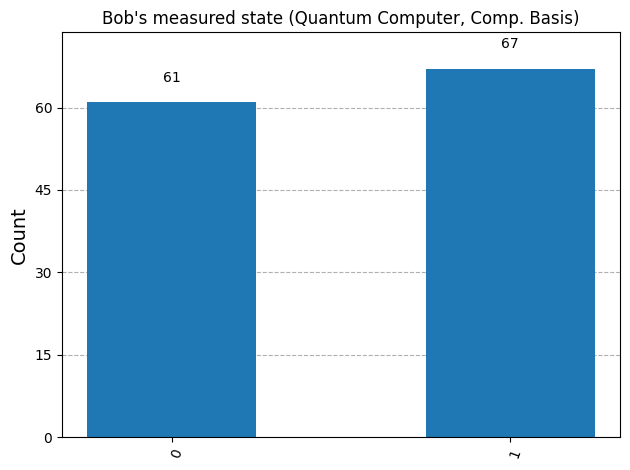

In [84]:
qc = QuantumCircuit(3,1)
qc.h(0)

qc.h(1)
qc.cx(1,2)
qc.cx(0,1)
qc.h(0)

qc.cx(1,2)
qc.cz(0,2)
qc.measure(2,0)

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Bob's measured state (Simulator, Comp. Basis)");

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Bob's measured state (Quantum Computer, Comp. Basis)");

Counts: {'0': 1024}


qiskit_runtime_service.__init__:WARNING:2026-02-14 18:18:55,503: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-14 18:18:56,168: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-14 18:18:57,646: Using instance: open-instance, plan: open


Counts: {'0': 122, '1': 6}


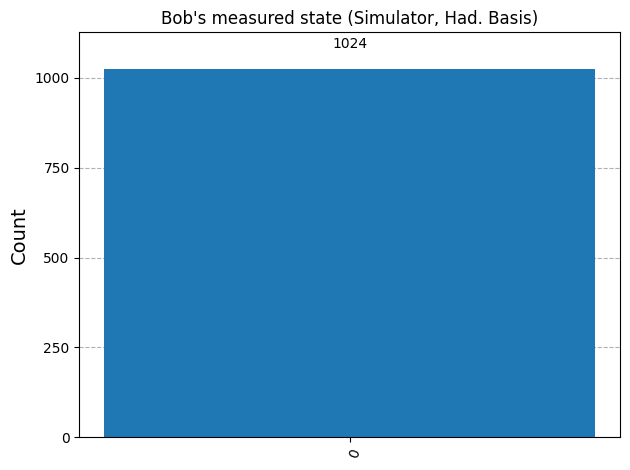

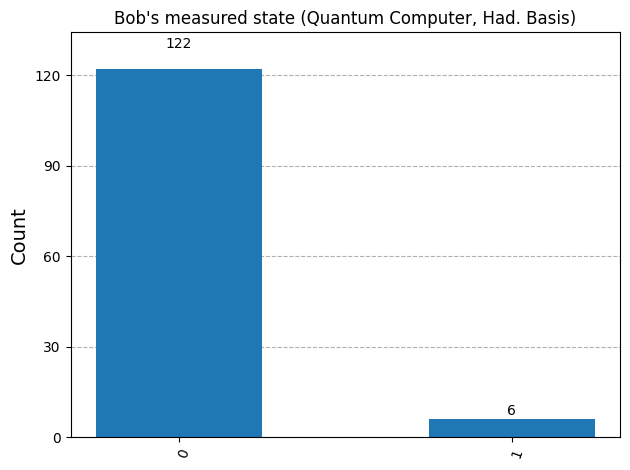

In [86]:
qc = QuantumCircuit(3,1)
qc.h(0)

qc.h(1)
qc.cx(1,2)
qc.cx(0,1)
qc.h(0)

qc.cx(1,2)
qc.cz(0,2)
qc.h(2)
qc.measure(2,0)

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Bob's measured state (Simulator, Had. Basis)");

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Bob's measured state (Quantum Computer, Had. Basis)");

## Problem 4

Counts: {'00': 1024}


qiskit_runtime_service.__init__:WARNING:2026-02-14 18:36:23,943: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-14 18:36:24,511: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-14 18:36:26,350: Using instance: open-instance, plan: open


Counts: {'00': 116, '10': 9, '11': 1, '01': 2}


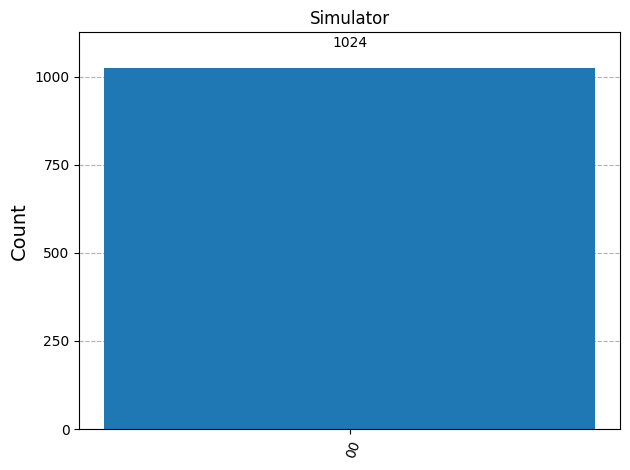

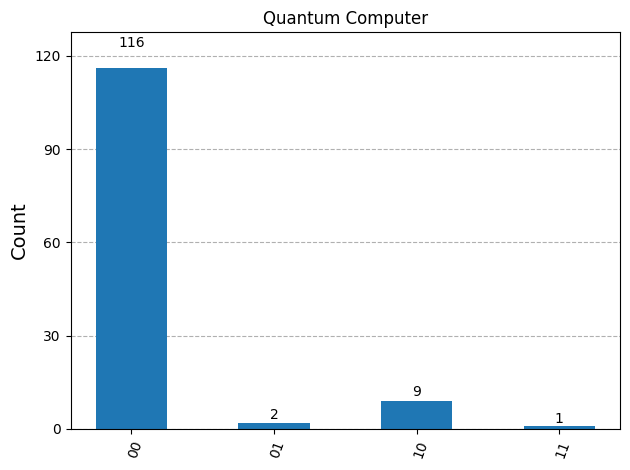

In [95]:
qc = QuantumCircuit(4,2)
qc.h(0)
qc.cx(0,3)

# Alice teleports to Bob
qc.h(1)
qc.cx(1,2)
qc.cx(0,1)
qc.h(0)
qc.cx(1,2)
qc.cz(0,2)

# measure in Bell basis
qc.cx(2, 3)
qc.h(2)
qc.measure(2, 0)
qc.measure(3, 1)

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Simulator");

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.c.get_counts()
print('Counts:', counts)
plot_histogram(counts, title="Quantum Computer");